Testing out pynaple and dandi env on this dataset: https://dandiarchive.org/dandiset/001695/0.260319.2023

In [19]:
import sys
# install into THIS kernel's interpreter (pynapple_dandi_env), not system python
!{sys.executable} -m pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 64.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [hmmlearn]1/3 [scikit-learn]


In [16]:
import sys
# sys.executable = the exact python running THIS kernel (your pynapple_dandi_env)
# using "-m pip" guarantees the matching pip, not whatever `pip` resolves to on PATH
!{sys.executable} -m pip install matplotlib
print("\nInstalled into:", sys.executable)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 59.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 34.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 18.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

Installed into: /storage/conda_envs/pynapple_dandi_env/bin/python


In [12]:
from pathlib import Path
from dandi.dandiapi import DandiAPIClient
import pynapple as nap

# ---- config ----
DANDISET_ID = "001695"
VERSION_ID  = "0.260319.2023"
SUBJECT     = "sub-M01/"                                  # which subject to scan
DOWNLOAD_DIR = Path("../../storage/dandi_downloads").resolve()
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)          # storage folder (create if missing)

# ---- discover sessions, pick smallest to keep it quick ----
with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, VERSION_ID)
    sessions = [(a.path, a.size)
                for a in dandiset.get_assets_with_path_prefix(SUBJECT, order="path")]
    # behavior+ecephys sessions are the ones with position data; prefer those
    behavior = [s for s in sessions if "behavior" in s[0]]
    pool = behavior or sessions                          # fall back to any if none flagged
    target_path = min(pool, key=lambda t: t[1])[0]       # smallest in the pool
    print("Picked:", target_path)

    # ---- download into storage (make nested sub-XX/ parent first) ----
    asset = dandiset.get_asset_by_path(target_path)
    asset_out = DOWNLOAD_DIR / target_path
    asset_out.parent.mkdir(parents=True, exist_ok=True)  # download() won't create dirs
    if not asset_out.exists():                           # skip re-download if already local
        asset.download(asset_out)
    print("Local file:", asset_out)

# ---- load in pynapple ----
data = nap.load_file(str(asset_out))
print("\nObjects in this NWB file:")
print(data)                                              # look here for position/behavior keys

# ---- find spatial-navigation data ----
# pynapple exposes NWB objects by key; spatial data is usually a TsdFrame of x/y
# common keys across datasets: "position", "SpatialSeries", "head_position", etc.
spatial_keys = [k for k in data.keys()
                if any(w in k.lower() for w in ["position", "spatial", "pos", "head"])]
print("\nCandidate spatial keys:", spatial_keys)

if spatial_keys:
    pos = data[spatial_keys[0]]                          # TsdFrame: columns are x/y (/z)
    print(f"\nUsing '{spatial_keys[0]}':")
    print(pos)
    print("Columns:", list(getattr(pos, "columns", [])))
    print("Time span (s):", pos.index[-1] - pos.index[0])
else:
    print("\nNo obvious spatial key — print(data) above to see actual object names.")

Picked: sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
Local file: /storage/dandi_downloads/sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb

Objects in this NWB file:
sub-M01_ses-20240313T100000_behavior+ecephys
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                        │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                       │ TsGroup     │
│ SleepStates                 │ IntervalSet │
│ Best_Ripple_channel_LFP_CA1 │ TsdFrame    │
│ Speed                       │ Tsd         │
│ Position                    │ TsdFrame    │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

Candidate spatial keys: ['Position']

Using 'Position':
Time (s)                  x        y
------------------  -------  -------
4892.8469000000005  10.2028  15.5703
4892.8872854166675  10.204   15.5773
4892.927670833334   10.204   15.5891
4892.968056250001   10.204   15.6471
4893.008441666667   10.2028  15.6471
4893.048827083334   10.1692  15.6471
48

In [23]:
import pynapple as nap
from pathlib import Path

asset_out = Path("../../storage/dandi_downloads/sub-M01/"
                 "sub-M01_ses-20240313T100000_behavior+ecephys.nwb").resolve()
data = nap.load_file(str(asset_out))

# ---- pynapple's view: top-level objects and their types ----
print("=" * 60)
print("PYNAPPLE OBJECTS")
print("=" * 60)
print(data)

# ---- units TsGroup: metadata columns + shape ----
units = data["units"]
print("\n" + "=" * 60)
print("UNITS (TsGroup)")
print("=" * 60)
print("n_units:", len(units))
print("metadata_columns:", list(units.metadata_columns))
print("\nfull metadata table:")
print(units.metadata)                     # every per-unit column, all rows

# ---- each non-units object: type, shape, columns, time span ----
print("\n" + "=" * 60)
print("OTHER OBJECTS")
print("=" * 60)
for key in data.keys():
    if key == "units":
        continue
    obj = data[key]
    line = f"{key:32s} {type(obj).__name__}"
    if hasattr(obj, "columns"):
        line += f"  cols={list(obj.columns)}"
    if hasattr(obj, "shape"):
        line += f"  shape={obj.shape}"
    if hasattr(obj, "index") and len(obj) > 0:
        line += f"  t=[{obj.index[0]:.1f}, {obj.index[-1]:.1f}]s"
    elif hasattr(obj, "start"):            # IntervalSet
        line += f"  n_intervals={len(obj)}"
    print(line)

# ---- raw NWB hierarchy (the underlying file, everything pynapple didn't surface) ----
print("\n" + "=" * 60)
print("RAW NWB TREE")
print("=" * 60)
try:
    import pynwb, h5py
    with pynwb.NWBHDF5IO(str(asset_out), mode="r") as io:
        nwb = io.read()
        print(nwb)                          # full NWB object: acquisition, processing, intervals, etc.
except Exception as e:
    print("Could not open raw NWB:", e)

PYNAPPLE OBJECTS
sub-M01_ses-20240313T100000_behavior+ecephys
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                        │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                       │ TsGroup     │
│ SleepStates                 │ IntervalSet │
│ Best_Ripple_channel_LFP_CA1 │ TsdFrame    │
│ Speed                       │ Tsd         │
│ Position                    │ TsdFrame    │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

UNITS (TsGroup)
n_units: 240
metadata_columns: ['rate', 'cell_type', 'cell_area', 'firing_rate', 'ab_ratio', 'burstIndex_Mizuseki2012', 'cv2', 'maxWaveformCh', 'troughToPeak', 'acg_tau_decay', 'acg_tau_rise', 'thetaModulationIndex', 'x_position_probe', 'y_position_probe']

full metadata table:
         rate           cell_type cell_area  firing_rate  ab_ratio  \
1    9.909396  Narrow Interneuron       CA3     9.909626 -0.535097   
2    7.957887  Narrow Interneuron       CA3     7.959234 -0.172564   
3    0.815371     

/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: end is not sorted. Cannot add metadata to unsorted end times. Sorting it and dropping metadata.
  data = nap.IntervalSet(df)
/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: Some starts precede the previous end. Joining them!
  data = nap.IntervalSet(df)
/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: epochs have changed, dropping metadata.
  data = nap.IntervalSet(df)


SleepStates                      IntervalSet  cols=[np.str_('start'), np.str_('end')]  shape=(59, 2)  t=[0.0, 58.0]s
Best_Ripple_channel_LFP_CA1      TsdFrame  cols=[0]  shape=(13985972, 1)  t=[0.0, 11188.8]s
Speed                            Tsd  shape=(40708,)  t=[4892.8, 6521.2]s
Position                         TsdFrame  cols=['x', 'y']  shape=(40708, 2)  t=[4892.8, 6521.2]s

RAW NWB TREE
root pynwb.file.NWBFile at 0x140435709344080
Fields:
  devices: {
    Neuropixels 2.0 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    ElectrodeGroup1 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experimenter: ['Mihály Vöröslakos']
  file_create_date: [datetime.datetime(2026, 1, 13, 16, 16, 18, 804970, tzinfo=tzoffset(None, -18000))]
  identifier: name
  institution: NYU
  intervals: {
    SleepStates <class 'pynwb.epoch.TimeIntervals'>
  }
  lab: Buzsáki Lab
  processing: {
    behavior <class 'pynwb.base.ProcessingModule'

Metadata columns on units: ['rate', 'cell_type', 'cell_area', 'firing_rate', 'ab_ratio', 'burstIndex_Mizuseki2012', 'cv2', 'maxWaveformCh', 'troughToPeak', 'acg_tau_decay', 'acg_tau_rise', 'thetaModulationIndex', 'x_position_probe', 'y_position_probe']

Counts (region x cell_type, with Total):
type  Total  Narrow Interneuron  Pyramidal Cell  Wide Interneuron
area                                                             
CA1     219                  43             162                14
CA3     121                  94              13                14
RSC     201                 102              44                55


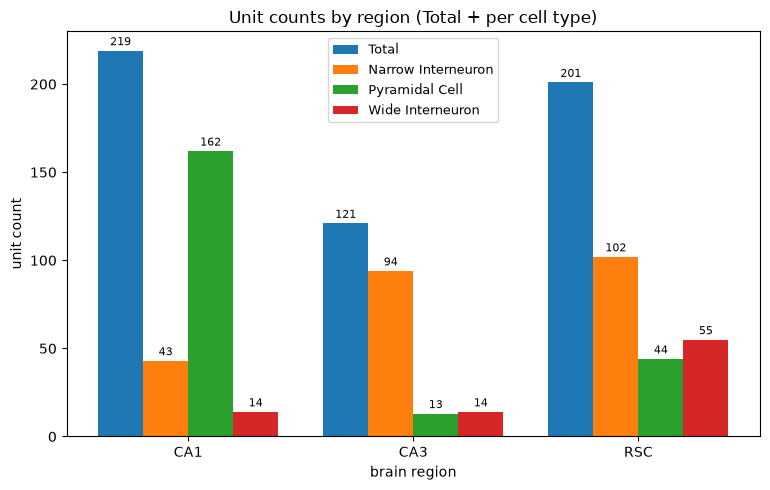

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# per-unit metadata available on the TsGroup (summary scores + labels, not spikes)
print("Metadata columns on units:", list(units.metadata_columns))

region_col = "cell_area"   # region label; 'cell_type' = narrow/wide interneuron etc.

regions = np.asarray(units.get_info(region_col))
cell_types = np.asarray(units.get_info("cell_type"))

# build a region x cell_type count table, then add a "Total" column
tab = pd.crosstab(pd.Series(regions, name="area"),
                  pd.Series(cell_types, name="type"))
tab.insert(0, "Total", tab.sum(axis=1))   # Total first, then each cell type
print("\nCounts (region x cell_type, with Total):")
print(tab)

# ---- grouped bar plot: regions on X, (Total + each cell_type) bars per region ----
areas = tab.index.tolist()          # X groups
cols = tab.columns.tolist()         # bars within each group: ['Total', type1, type2, ...]
n_bars = len(cols)
x = np.arange(len(areas))
width = 0.8 / n_bars                 # fit all bars within each region slot

fig, ax = plt.subplots(figsize=(1.6 * len(areas) + 3, 5))
cmap = plt.get_cmap("tab10")

for i, col in enumerate(cols):
    offsets = x + (i - (n_bars - 1) / 2) * width   # center the group on the tick
    bars = ax.bar(offsets, tab[col].values, width,
                  label=col, color=cmap(i))
    ax.bar_label(bars, padding=2, fontsize=8)      # count above each bar

ax.set_xticks(x); ax.set_xticklabels(areas)
ax.set(xlabel="brain region", ylabel="unit count",
       title="Unit counts by region (Total + per cell type)")
ax.legend(title="", fontsize=9)
plt.tight_layout(); plt.show()

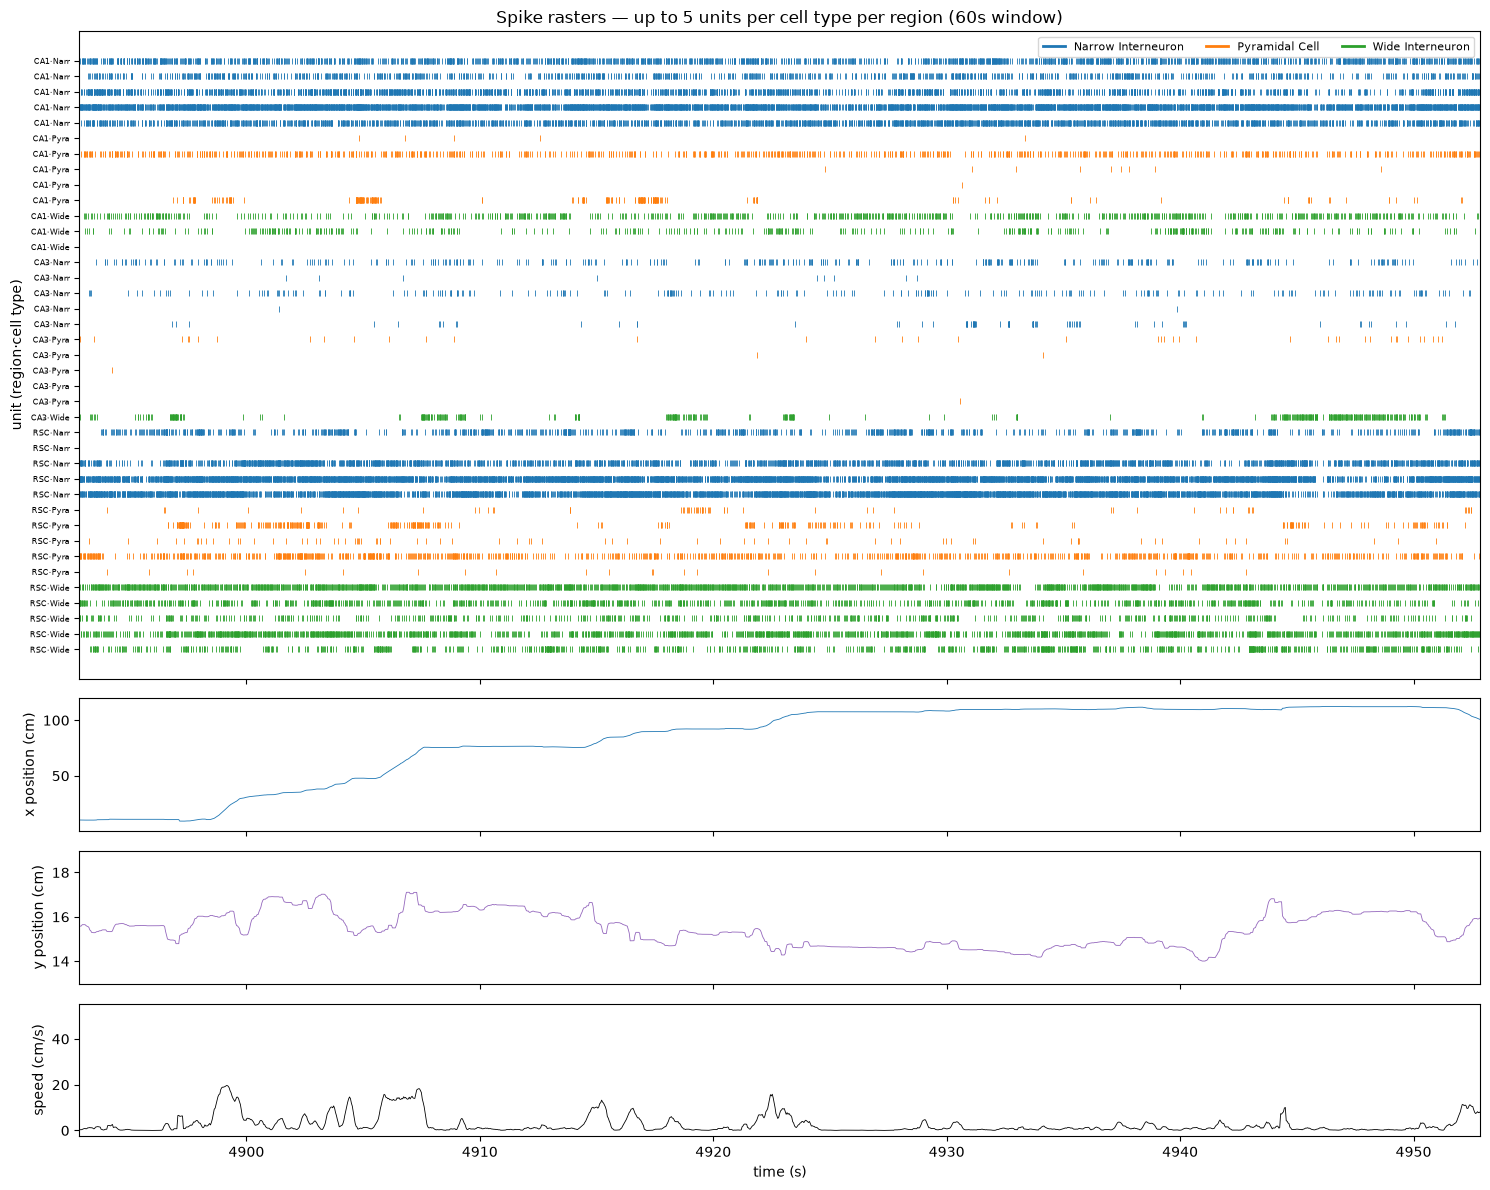

Showing 39 units | window 4893–4953 s


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import pynapple as nap

# ---- reload objects from the file so the cell stands alone ----
session_nwb_path = Path("../../storage/dandi_downloads/sub-M01/"
                        "sub-M01_ses-20240313T100000_behavior+ecephys.nwb").resolve()
session_nwb  = nap.load_file(str(session_nwb_path))
spike_group  = session_nwb["units"]        # TsGroup: 240 units, spike times + per-unit metadata
position_xy  = session_nwb["Position"]      # TsdFrame x/y, maze epoch only

n_units_per_group = 5     # neurons to show per (region, cell_type) combo
raster_window_s   = 60    # seconds to display in the raster (short window so spikes are legible)

# ---- compute running speed from position (not reliably provided in the file) ----
position_time_s = position_xy.index.values
position_x_vals = position_xy["x"].values
position_y_vals = position_xy["y"].values
# instantaneous speed = distance between consecutive samples / dt  (units: position-units / s)
dt_s = np.diff(position_time_s)
dxy = np.sqrt(np.diff(position_x_vals)**2 + np.diff(position_y_vals)**2)
speed_vals = dxy / dt_s
speed_time_s = position_time_s[1:]               # speed is defined between samples
# light smoothing over ~0.25 s to reduce sample-to-sample jitter
smooth_n = max(1, int(0.25 / np.median(dt_s)))
speed_vals_smooth = np.convolve(speed_vals, np.ones(smooth_n)/smooth_n, mode="same")

# ---- per-unit metadata arrays ----
unit_brain_regions = np.asarray(spike_group.get_info("cell_area"))   # CA1 / CA3 / RSC
unit_cell_types    = np.asarray(spike_group.get_info("cell_type"))   # Narrow/Wide Interneuron, Pyramidal Cell
unit_id_keys       = np.asarray(spike_group.index)                   # 1-based unit keys

cell_type_names  = sorted(set(unit_cell_types))
cell_type_colors = {ct: c for ct, c in zip(cell_type_names, plt.get_cmap("tab10").colors)}

# ---- pick up to n neurons per region x cell_type ----
selected_units = []   # (unit_id, brain_region, cell_type)
for brain_region in sorted(set(unit_brain_regions)):
    for cell_type in cell_type_names:
        matching_unit_ids = unit_id_keys[(unit_brain_regions == brain_region)
                                         & (unit_cell_types == cell_type)]
        for unit_id in matching_unit_ids[:n_units_per_group]:
            selected_units.append((unit_id, brain_region, cell_type))

# ---- display window: first raster_window_s of the maze epoch ----
window_start_s = position_time_s[0]
window_end_s   = window_start_s + raster_window_s

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True,
                         gridspec_kw={"height_ratios": [len(selected_units)/8, 1, 1, 1]})

# ---- panel 0: spike raster (windowed) ----
raster_ax = axes[0]
for raster_row, (unit_id, brain_region, cell_type) in enumerate(selected_units):
    unit_spike_times = spike_group[unit_id].get(window_start_s, window_end_s)
    raster_ax.plot(unit_spike_times.index.values,
                   np.full(len(unit_spike_times), raster_row), "|",
                   color=cell_type_colors[cell_type], markersize=4, mew=0.6)
raster_ax.set_yticks(range(len(selected_units)))
raster_ax.set_yticklabels([f"{r[:4]}·{c[:4]}" for _, r, c in selected_units], fontsize=6)
raster_ax.set(ylabel="unit (region·cell type)",
              title=f"Spike rasters — up to 5 units per cell type per region "
                    f"({raster_window_s}s window)")
raster_ax.invert_yaxis()
raster_ax.legend(handles=[Line2D([0],[0], color=cell_type_colors[ct], lw=2, label=ct)
                          for ct in cell_type_names],
                 fontsize=8, loc="upper right", ncol=len(cell_type_names))

# ---- panels 1 & 2: position x and y ----
axes[1].plot(position_time_s, position_x_vals, lw=0.6, color="tab:blue")
axes[1].set(ylabel="x position (cm)")
axes[2].plot(position_time_s, position_y_vals, lw=0.6, color="tab:purple")
axes[2].set(ylabel="y position (cm)")

# ---- panel 3: computed running speed ----
axes[3].plot(speed_time_s, speed_vals_smooth, lw=0.6, color="k")
axes[3].set(ylabel="speed (cm/s)", xlabel="time (s)")

axes[0].set_xlim(window_start_s, window_end_s)   # all panels locked to the window
plt.tight_layout(); plt.show()

print(f"Showing {len(selected_units)} units | window {window_start_s:.0f}–{window_end_s:.0f} s")

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

# ---- rebuild the spike matrix (kernel lost Xz after the restart) ----
BIN = 0.010                                    # 10 ms bins
counts_bin = units.count(BIN)                  # TsdFrame [T bins x N units]
t = counts_bin.index.values                    # real experiment time (s), length T
X = counts_bin.values.astype(float)

totals = X.sum(axis=1, keepdims=True); totals[totals == 0] = 1
Xn = X / totals                                # normalize each bin by population total
mu, sd = Xn.mean(0), Xn.std(0); sd[sd == 0] = 1
Xz = (Xn - mu) / sd                            # z-score each neuron -> variance-stabilized

# ---- HMM param count for AIC/BIC (diag cov): transitions+start+means+covs ----
def hmm_param_count(model, n_features):
    n = model.n_components
    return n*(n-1) + (n-1) + n*n_features + n*n_features

# ---- sweep 10 -> 2 states ----
rows, models = [], {}
for k in range(10, 1, -1):
    m = GaussianHMM(n_components=k, covariance_type="diag", n_iter=100, random_state=0)
    m.fit(Xz)                                  # rows are an ordered sequence -> temporal structure used
    ll = m.score(Xz)
    p = hmm_param_count(m, Xz.shape[1]); n_obs = Xz.shape[0]
    rows.append({"n_states": k, "loglik": ll,
                 "AIC": -2*ll + 2*p, "BIC": -2*ll + p*np.log(n_obs), "n_params": p})
    models[k] = m

scores = pd.DataFrame(rows).set_index("n_states").sort_index()
print(scores)

# ---- plot AIC / BIC / log-likelihood ----
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(scores.index, scores["AIC"], "o-");                       ax[0].set(title="AIC (lower=better)", xlabel="n states")
ax[1].plot(scores.index, scores["BIC"], "o-", color="tab:orange");   ax[1].set(title="BIC (lower=better)", xlabel="n states")
ax[2].plot(scores.index, scores["loglik"], "o-", color="tab:green"); ax[2].set(title="log-likelihood", xlabel="n states")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- decode BIC-preferred model: Viterbi (temporally smoothed) + transition matrix ----
K = int(scores["BIC"].idxmin())
model = models[K]
states = model.predict(Xz)                     # smoothed state path (not printed)
T_mat = model.transmat_                         # HMM's learned transition matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [3, 1]})
axes[0].scatter(t, states, c=states, cmap="tab10", s=2, marker="s")
axes[0].set(xlabel="time (s)", ylabel="state", yticks=range(K),
            title=f"HMM states over experiment (K={K}, BIC-preferred, Viterbi)")
im = axes[1].imshow(T_mat, cmap="viridis", vmin=0, vmax=1)
axes[1].set(xlabel="to", ylabel="from", xticks=range(K), yticks=range(K), title="Transition matrix")
for i in range(K):
    for j in range(K):
        axes[1].text(j, i, f"{T_mat[i,j]:.2f}", ha="center", va="center",
                     color="w" if T_mat[i,j] < 0.6 else "k", fontsize=7)
fig.colorbar(im, ax=axes[1], label="P(to|from)")
plt.tight_layout(); plt.show()

KeyboardInterrupt: 